In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_1719.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_3945.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_0456.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_3324.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_3968.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_3864.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_0208.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_2517.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_3435.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/FCT_1875.png
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage/stage1/F

In [5]:
!cp -r /kaggle/input/datasets/sudeeppatali/crc-project-code/crc_project /kaggle/working/
%cd /kaggle/working/crc_project

/kaggle/working/crc_project


In [6]:
!pip install albumentations optuna -q

In [7]:
import albumentations, optuna
print("albumentations:", albumentations.__version__)
print("optuna:", optuna.__version__)

albumentations: 2.0.8
optuna: 4.9.0


In [8]:
!ls /kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/

binary	stage


In [9]:
import config, os

config.DATASET_ROOT   = "/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset"
config.BINARY_DIR     = config.DATASET_ROOT + "/binary"
config.STAGE_DIR       = config.DATASET_ROOT + "/stage"
config.CHECKPOINT_DIR = "/kaggle/working/checkpoints"
config.REPORT_DIR     = "/kaggle/working/reports"

os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.REPORT_DIR, exist_ok=True)

print(config.BINARY_DIR)
print(config.STAGE_DIR)

/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/binary
/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset/stage


In [10]:
from utils.dataset import build_dataloaders
train_loader, val_loader, test_loader = build_dataloaders(config.BINARY_DIR, config.BINARY_CLASSES)

[binary] train=6000 val=1500 test=2500


In [11]:
stage_train_loader, stage_val_loader, stage_test_loader = build_dataloaders(config.STAGE_DIR, config.STAGE_CLASSES)

[stage] train=11999 val=2999 test=5001


In [12]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True Tesla T4


In [13]:
config_path = "/kaggle/working/crc_project/config.py"

with open(config_path, "r") as f:
    content = f.read()

content = content.replace(
    'DATASET_ROOT   = os.path.join(PROJECT_ROOT, "dataset")',
    'DATASET_ROOT   = "/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset"'
)

with open(config_path, "w") as f:
    f.write(content)

print("Updated!")

Updated!


In [14]:
!grep DATASET_ROOT /kaggle/working/crc_project/config.py


DATASET_ROOT   = "/kaggle/input/datasets/sudeeppatali/crc-histopath-dataset/dataset"
BINARY_DIR     = os.path.join(DATASET_ROOT, "binary")   # NOR / TUM
STAGE_DIR      = os.path.join(DATASET_ROOT, "stage")    # stage0..stage3


In [15]:
!grep -E "CHECKPOINT_DIR|REPORT_DIR" /kaggle/working/crc_project/config.py

CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
REPORT_DIR     = os.path.join(PROJECT_ROOT, "reports")
for d in [CHECKPOINT_DIR, LOG_DIR, REPORT_DIR, WSI_PATCH_DIR]:


In [16]:
!python scripts/train.py --task binary

[binary] train=6000 val=1500 test=2500
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|███████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 207MB/s]
[binary] epoch 1/40 train_loss=0.0305 val_loss=0.0047 val_acc=0.9973 val_f1=0.9973
[binary] epoch 2/40 train_loss=0.0122 val_loss=0.0037 val_acc=0.9960 val_f1=0.9960
[binary] epoch 3/40 train_loss=0.0101 val_loss=0.0059 val_acc=0.9960 val_f1=0.9960
[binary] epoch 4/40 train_loss=0.0087 val_loss=0.0085 val_acc=0.9920 val_f1=0.9920
[binary] epoch 5/40 train_loss=0.0127 val_loss=0.0044 val_acc=0.9960 val_f1=0.9960
[binary] epoch 6/40 train_loss=0.0072 val_loss=0.0042 val_acc=0.9947 val_f1=0.9947
[binary] epoch 7/40 train_loss=0.0075 val_loss=0.0042 val_acc=0.9953 val_f1=0.9953
[binary] epoch 8/40 train_loss=0.0073 val_loss=0.0028 val_acc=0.9980 val_f1=0.9980
[binary] epoch 9/40 train_loss=0.0067 val_loss=0.

In [17]:
!python scripts/train.py --task stage

[stage] train=11999 val=2999 test=5001
[stage] epoch 1/40 train_loss=0.0688 val_loss=0.0112 val_acc=0.9970 val_f1=0.9970
[stage] epoch 2/40 train_loss=0.0308 val_loss=0.0109 val_acc=0.9967 val_f1=0.9967
[stage] epoch 3/40 train_loss=0.0233 val_loss=0.0091 val_acc=0.9993 val_f1=0.9993
[stage] epoch 4/40 train_loss=0.0224 val_loss=0.0098 val_acc=0.9963 val_f1=0.9963
[stage] epoch 5/40 train_loss=0.0280 val_loss=0.0093 val_acc=0.9997 val_f1=0.9997
[stage] epoch 6/40 train_loss=0.0191 val_loss=0.0082 val_acc=0.9990 val_f1=0.9990
[stage] epoch 7/40 train_loss=0.0145 val_loss=0.0091 val_acc=0.9977 val_f1=0.9977
[stage] epoch 8/40 train_loss=0.0236 val_loss=0.0085 val_acc=0.9990 val_f1=0.9990
[stage] epoch 9/40 train_loss=0.0186 val_loss=0.0123 val_acc=0.9960 val_f1=0.9960
[stage] epoch 10/40 train_loss=0.0156 val_loss=0.0191 val_acc=0.9903 val_f1=0.9903
[stage] epoch 11/40 train_loss=0.0152 val_loss=0.0080 val_acc=0.9993 val_f1=0.9993
[stage] epoch 12/40 train_loss=0.0117 val_loss=0.0078 val

In [18]:
!python scripts/evaluate.py --task binary
!python scripts/evaluate.py --task stage

[binary] train=6000 val=1500 test=2500

===== BINARY MODEL - TEST SET REPORT =====
              precision    recall  f1-score   support

         NOR     0.9984    0.9976    0.9980      1250
         TUM     0.9976    0.9984    0.9980      1250

    accuracy                         0.9980      2500
   macro avg     0.9980    0.9980    0.9980      2500
weighted avg     0.9980    0.9980    0.9980      2500

Confusion matrix saved -> /kaggle/working/crc_project/reports/binary_confusion_matrix.png
ROC curve saved -> /kaggle/working/crc_project/reports/binary_roc_curve.png
[stage] train=11999 val=2999 test=5001

===== STAGE MODEL - TEST SET REPORT =====
              precision    recall  f1-score   support

      stage0     0.9960    0.9976    0.9968      1250
      stage1     0.9960    0.9960    0.9960      1250
      stage2     0.9976    0.9944    0.9960      1250
      stage3     0.9984    1.0000    0.9992      1251

    accuracy                         0.9970      5001
   macro avg    

In [19]:
!ls -la /kaggle/working/crc_project/checkpoints/

total 60400
drwxr-xr-x  2 root root     4096 Aug  1 18:37 .
drwxr-xr-x 10 root root     4096 Aug  1 18:16 ..
-rw-r--r--  1 root root 30919225 Aug  1 18:29 binary_best.pt
-rw-r--r--  1 root root 30919810 Aug  1 18:43 stage_best.pt


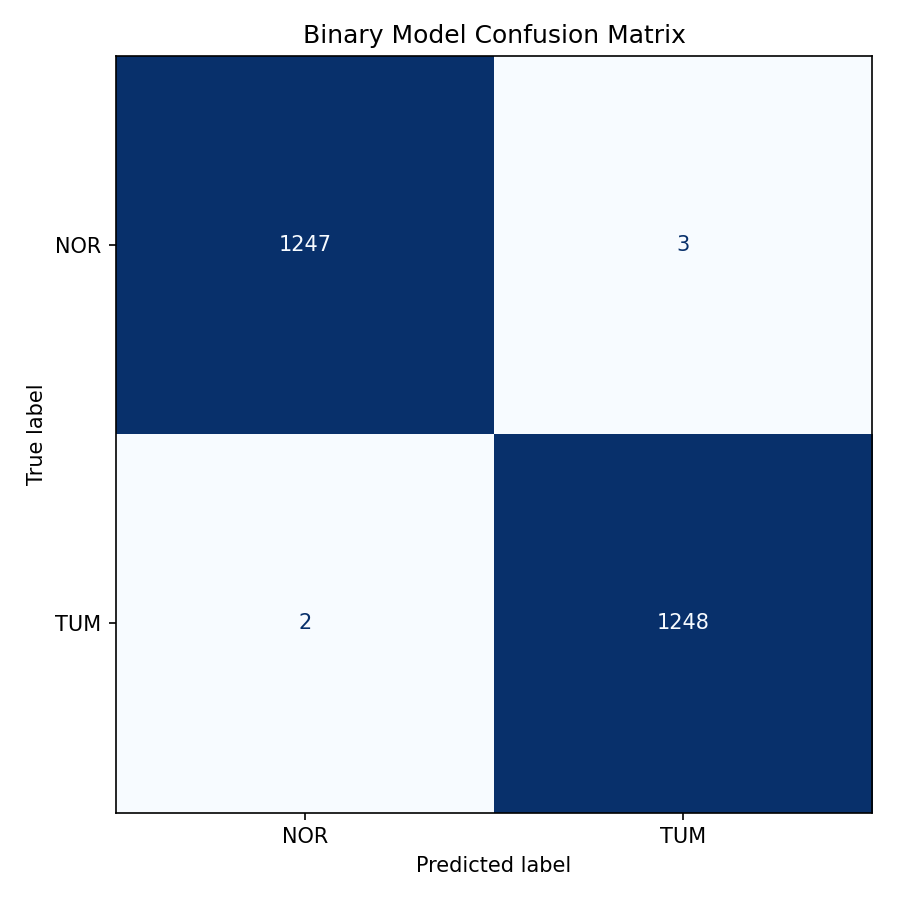

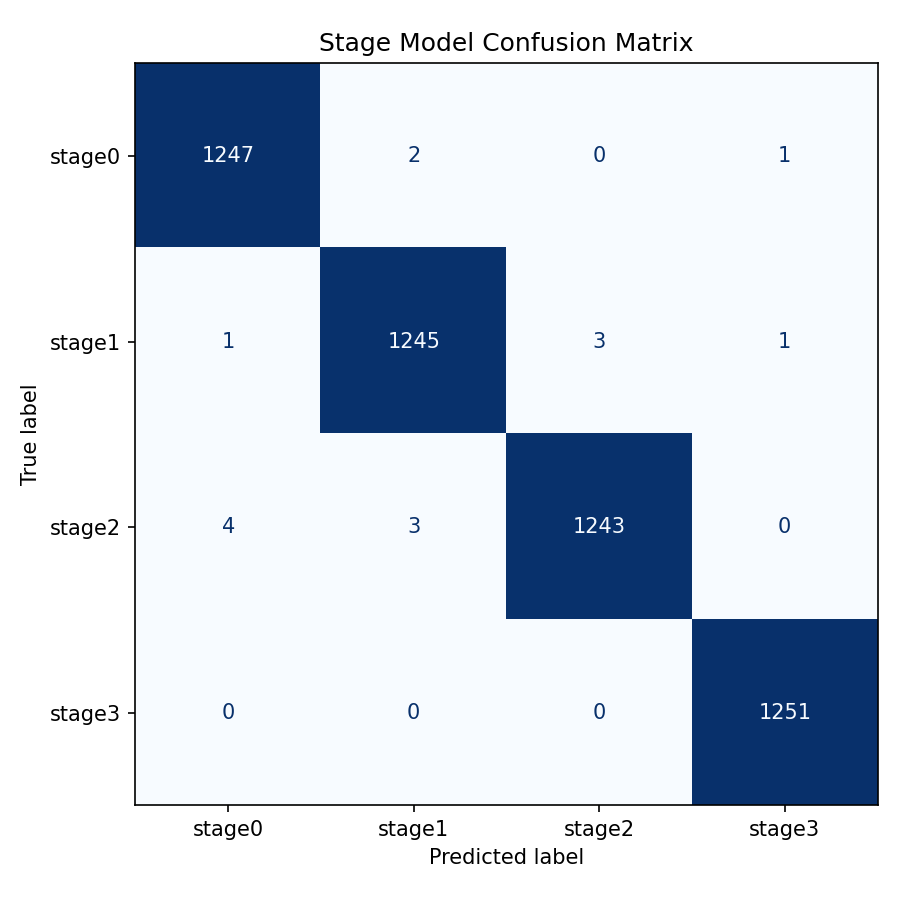

In [20]:
from IPython.display import Image, display
display(Image("/kaggle/working/crc_project/reports/binary_confusion_matrix.png"))
display(Image("/kaggle/working/crc_project/reports/stage_confusion_matrix.png"))